# 从零开始实现

- 权重衰退时最广泛使用的正则化方法。 

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

- 生成人工数据集
$$y = 0.05 + \sum_{i=1}^{d} 0.01x_i + \epsilon \quad \text{where } \epsilon \sim \mathcal{N}(0, 0.01^2)$$

In [2]:
n_train, n_test, num_inputs = 20, 100, 200
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size=5)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size=5, is_train=False)


- 初始化模型参数


In [3]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

- 定义L1范数惩罚

In [4]:
def l1_penalty(w):
    return torch.abs(w).sum()

- 定义L2范数惩罚

In [5]:
def l2_penalty(w):
    # landa不会直接写进来，会写在超参数里
    return torch.sum(w.pow(2)) / 2

- 定义训练代码实现

In [ ]:
def train1(lambd): # L1范数惩罚
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            # l = loss(net(X), y) + lambd * l2_penalty(w)
            l = loss(net(X), y) + lambd * l1_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size=5)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('L1 norm of w:', torch.norm(w).item())

In [ ]:
def train2(lambd): # L2范数惩罚
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            l = loss(net(X), y) + lambd * l2_penalty(w)
            # l = loss(net(X), y) + lambd * l1_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size=5)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('L2 norm of w:', torch.norm(w).item())

- 忽略正则化直接训练

L1 norm of w: 14.9942626953125


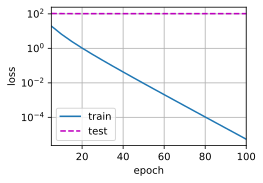

In [19]:
train1(lambd=0)

L2 norm of w: 15.869174003601074


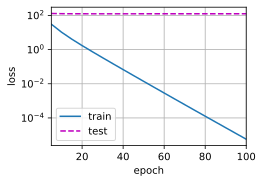

In [11]:
train2(lambd=0)  # 不使用权重衰退

- 可以看出gap很大，是过拟合的标志，train的loss越来越小，但是test的loss却变化不大

- 使用权重衰退训练

L1 norm of w: 0.07424159348011017


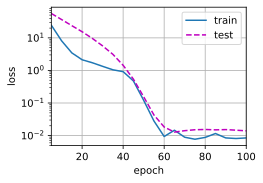

In [18]:
train1(lambd=3)

L2 norm of w: 0.3701523244380951


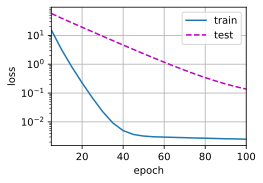

In [17]:
train2(lambd=3)  # 使用权重衰退

- 效果先对于前面的训练有了明显的提升，gap变小了，说明过拟合得到了缓解

# 简洁实现

In [8]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_(0, 1)
    loss = nn.MSELoss()
    num_epochs, lr = 100, 0.003
    trainer = torch.optim.SGD([
        {'params': net[0].weight, 'weight_decay': wd},
        {'params': net[0].bias}
    ], lr=lr)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('L2 norm of w:', net[0].weight.norm().item())

L2 norm of w: 12.122157096862793


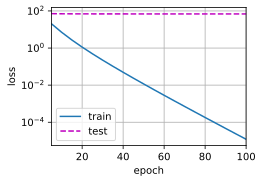

In [ ]:
train(wd=0)  # 不使用权重衰退

L2 norm of w: 0.34357592463493347


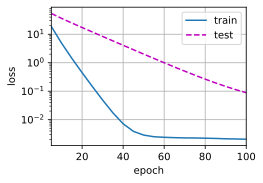

In [ ]:
train(wd=3)  # 使用权重衰退

L2 norm of w: 0.194610595703125


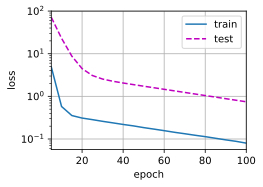

In [15]:
train_concise(10)